In [22]:
!pip install numpy pandas matplotlib librosa soundfile


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

In [24]:
PROJECT_ROOT = Path.cwd().parent

RAVDESS_DIR = PROJECT_ROOT / "data" / "speech" / "ravdess"
CREMAD_DIR = PROJECT_ROOT / "data" / "speech" / "crema_d"

METADATA_DIR = PROJECT_ROOT / "data" / "metadata"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

METADATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
ravdess_files = list(RAVDESS_DIR.rglob("*.wav"))
print("RAVDESS files:", len(ravdess_files))
print("First file:", ravdess_files[0])

cremad_files = list(CREMAD_DIR.rglob("*.wav"))
print("CREMA-D files:", len(cremad_files))
print("First file:", cremad_files[0])

RAVDESS files: 2880
First file: c:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\speech\ravdess\Actor_01\03-01-01-01-01-01-01.wav
CREMA-D files: 7442
First file: c:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\speech\crema_d\AudioWAV\1001_DFA_ANG_XX.wav


In [26]:
RAVDESS_EMOTIONS = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}


def parse_ravdess(path):
    parts = path.stem.split("-")

    return {
        "dataset": "RAVDESS",
        "file": str(path),
        "speaker": int(parts[6]),
        "emotion": RAVDESS_EMOTIONS[int(parts[2])],
        "emotion_id": int(parts[2])
    }
ravdess_metadata = pd.DataFrame(
    [parse_ravdess(file) for file in ravdess_files]
)

ravdess_metadata.head()

,dataset,file,speaker,emotion,emotion_id
0,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
1,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
2,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
3,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
4,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,calm,2


In [27]:
ravdess_metadata["emotion"].value_counts()


emotion
calm         384
happy        384
sad          384
angry        384
fearful      384
disgust      384
surprised    384
neutral      192
Name: count, dtype: int64

In [28]:
ravdess_metadata["speaker"].nunique()

24

In [29]:
CREMAD_EMOTIONS = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fearful",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}


def parse_cremad(path):
    parts = path.stem.split("_")

    return {
        "dataset": "CREMA-D",
        "file": str(path),
        "speaker": int(parts[0]),
        "emotion": CREMAD_EMOTIONS[parts[2]],
        "emotion_id": parts[2]
    }
cremad_metadata = pd.DataFrame(
    [parse_cremad(file) for file in cremad_files]
)
cremad_metadata.head()

,dataset,file,speaker,emotion,emotion_id
0,CREMA-D,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1001,angry,ANG
1,CREMA-D,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1001,disgust,DIS
2,CREMA-D,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1001,fearful,FEA
3,CREMA-D,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1001,happy,HAP
4,CREMA-D,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1001,neutral,NEU


In [30]:
cremad_metadata["emotion"].value_counts()

emotion
angry      1271
disgust    1271
fearful    1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64

In [31]:
cremad_metadata["speaker"].nunique()

91

In [32]:
speech_metadata = pd.concat(
    [ravdess_metadata, cremad_metadata],
    ignore_index=True
)

speech_metadata.head()

,dataset,file,speaker,emotion,emotion_id
0,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
1,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
2,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
3,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,neutral,1
4,RAVDESS,c:\Users\18045\OneDrive\Documents\Coding\sem7\...,1,calm,2


Total files: 10322
Datasets:
dataset
CREMA-D    7442
RAVDESS    2880
Name: count, dtype: int64
Saved to: c:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\metadata\speech_metadata.csv


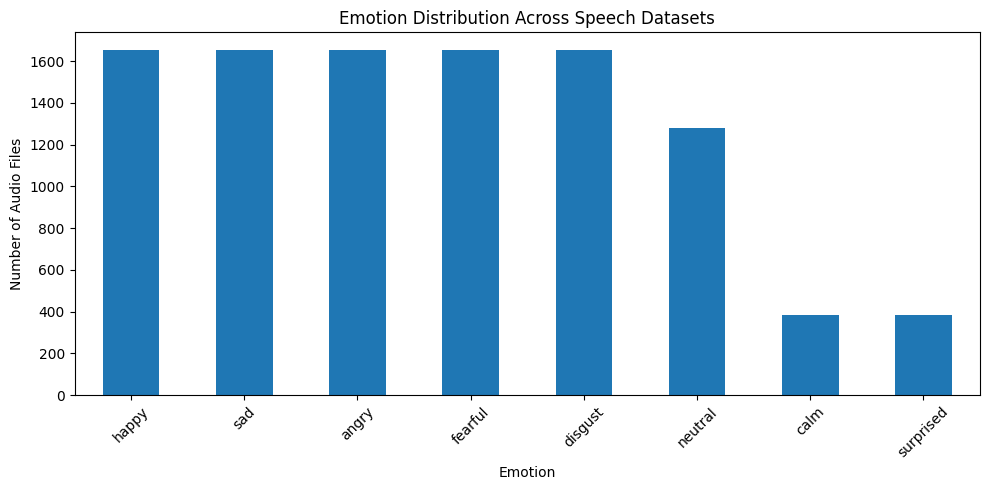

In [33]:
print("Total files:", len(speech_metadata))
print("Datasets:")
print(speech_metadata["dataset"].value_counts())
metadata_path = METADATA_DIR / "speech_metadata.csv"

speech_metadata.to_csv(metadata_path, index=False)

print(f"Saved to: {metadata_path}")
emotion_counts = speech_metadata["emotion"].value_counts()
plt.figure(figsize=(10, 5))
emotion_counts.plot(kind="bar")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.title("Emotion Distribution Across Speech Datasets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Samples: 158558
Sample rate: 48000
Duration: 3.3032916666666665 seconds


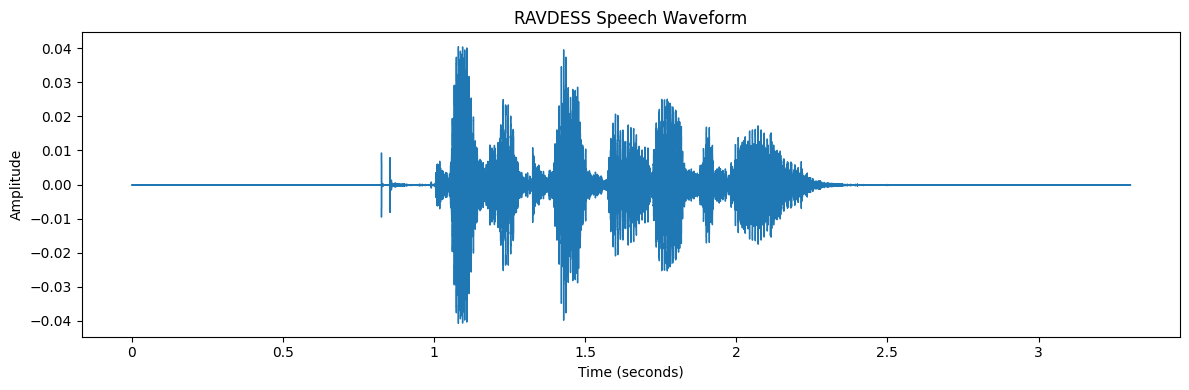

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_waveform.png


In [34]:
audio_path = ravdess_files[0]
y, sr = librosa.load(audio_path, sr=None)

print("Samples:", len(y))
print("Sample rate:", sr)
print("Duration:", len(y) / sr, "seconds")

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("RAVDESS Speech Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()

waveform_path = FIGURES_DIR / "speech_waveform.png"
plt.savefig(waveform_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved to: {waveform_path.resolve()}")

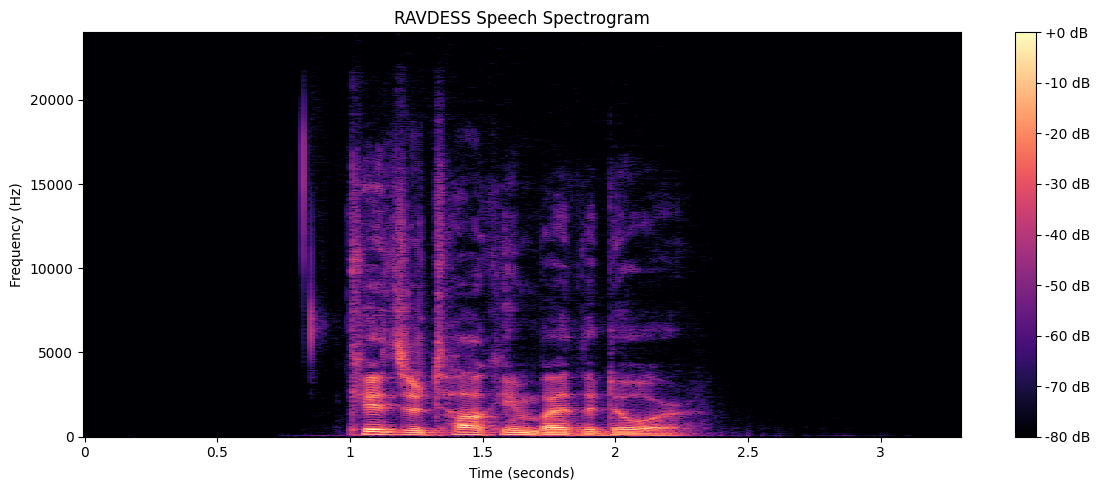

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_spectrogram.png


In [35]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(
    np.abs(D),
    ref=np.max
)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("RAVDESS Speech Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()

spectrogram_path = FIGURES_DIR / "speech_spectrogram.png"
plt.savefig(spectrogram_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved to: {spectrogram_path.resolve()}")

In [36]:
f0, voiced_flag, voiced_prob = librosa.pyin(
    y,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7"),
    sr=sr
)
f0


array([         nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,       

Pitch frames: 310
Minimum F0: 65.40639132514966
Maximum F0: 145.9866916572425
Mean F0: 101.16483249691709


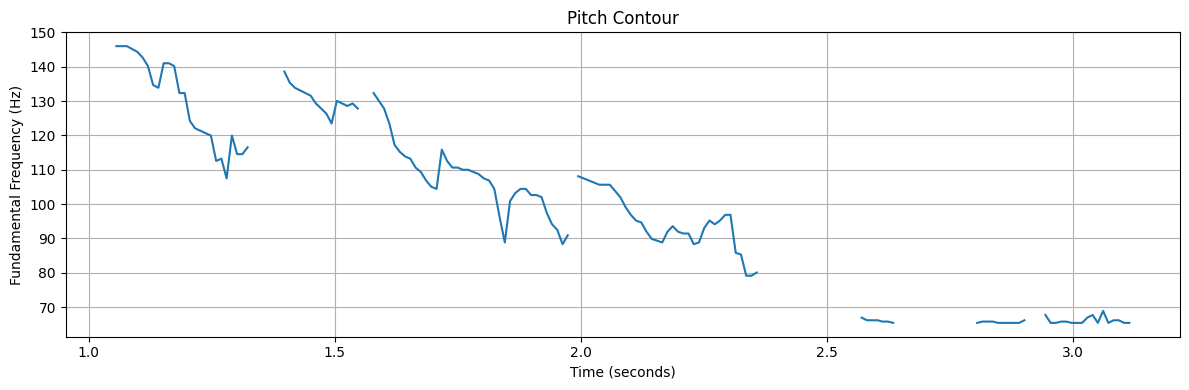

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_pitch_contour.png


In [37]:
print("Pitch frames:", len(f0))
print("Minimum F0:", np.nanmin(f0))
print("Maximum F0:", np.nanmax(f0))
print("Mean F0:", np.nanmean(f0))
times = librosa.times_like(f0, sr=sr)
plt.figure(figsize=(12, 4))
plt.plot(times, f0)
plt.title("Pitch Contour")
plt.xlabel("Time (seconds)")
plt.ylabel("Fundamental Frequency (Hz)")
plt.grid(True)
plt.tight_layout()

pitch_path = FIGURES_DIR / "speech_pitch_contour.png"
plt.savefig(pitch_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved to: {pitch_path.resolve()}")

RMS frames: 310
Mean RMS: 0.0021197072
Maximum RMS: 0.01582806


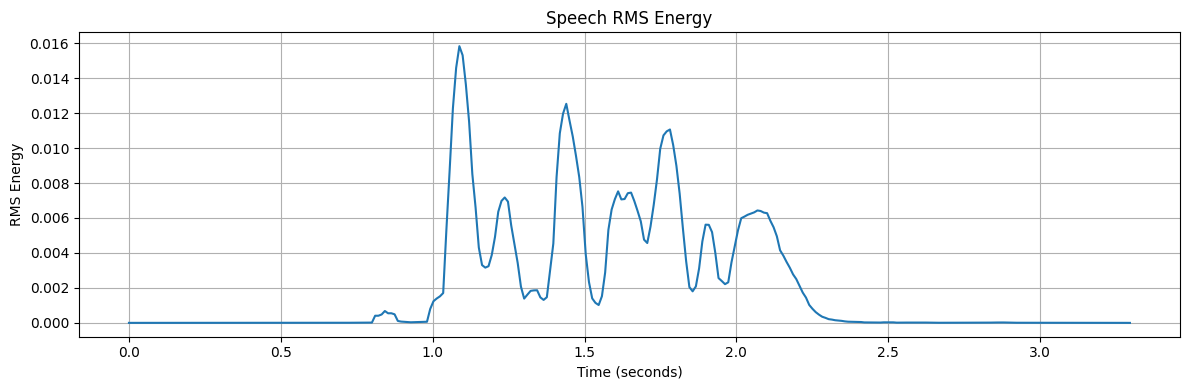

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_energy.png


In [38]:
rms = librosa.feature.rms(y=y)[0]

print("RMS frames:", len(rms))
print("Mean RMS:", np.mean(rms))
print("Maximum RMS:", np.max(rms))
rms_times = librosa.times_like(rms, sr=sr)

plt.figure(figsize=(12, 4))

plt.plot(rms_times, rms)

plt.title("Speech RMS Energy")
plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")
plt.grid(True)

plt.tight_layout()

energy_path = FIGURES_DIR / "speech_energy.png"
plt.savefig(energy_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved to: {energy_path.resolve()}")

Mean ZCR: 0.05047568044354839
Maximum ZCR: 0.27880859375


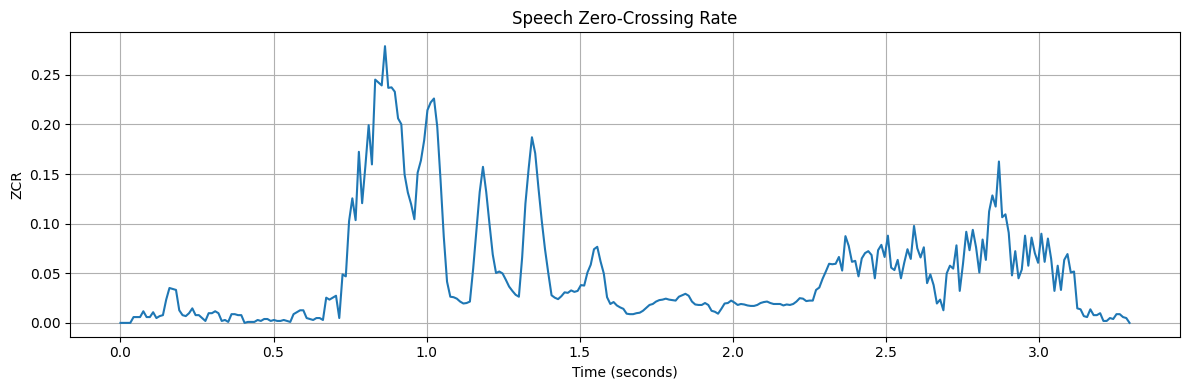

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_zcr.png


In [39]:
zcr = librosa.feature.zero_crossing_rate(y)[0]
print("Mean ZCR:", np.mean(zcr))
print("Maximum ZCR:", np.max(zcr))

zcr_times = librosa.times_like(zcr, sr=sr)
plt.figure(figsize=(12, 4))
plt.plot(zcr_times, zcr)
plt.title("Speech Zero-Crossing Rate")
plt.xlabel("Time (seconds)")
plt.ylabel("ZCR")
plt.grid(True)
plt.tight_layout()

zcr_path = FIGURES_DIR / "speech_zcr.png"
plt.savefig(zcr_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved to: {zcr_path.resolve()}")

MFCC shape: (13, 310)
Number of coefficients: 13
Number of frames: 310


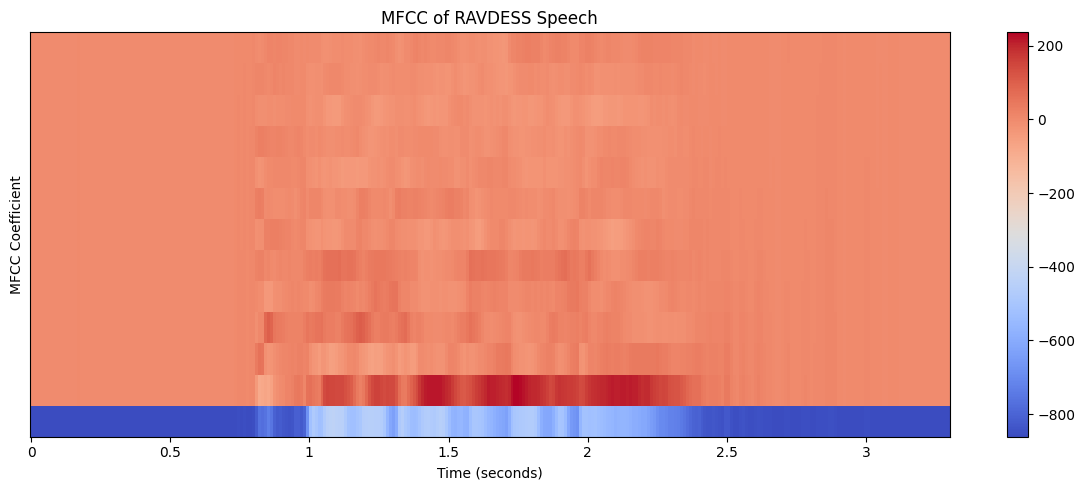

Saved to: C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\outputs\figures\speech_mfcc.png


In [40]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)
print("MFCC shape:", mfcc.shape)
print("Number of coefficients:", mfcc.shape[0])
print("Number of frames:", mfcc.shape[1])

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)
plt.colorbar()
plt.title("MFCC of RAVDESS Speech")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficient")
plt.tight_layout()

mfcc_path = FIGURES_DIR / "speech_mfcc.png"
plt.savefig(mfcc_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close()

print(f"Saved to: {mfcc_path.resolve()}")

In [41]:
import parselmouth
sound = parselmouth.Sound(str(audio_path))
point_process = parselmouth.praat.call(
    sound,
    "To PointProcess (periodic, cc)",
    75,
    500
)
jitter = parselmouth.praat.call(
    point_process,
    "Get jitter (local)",
    0,
    0,
    0.0001,
    0.02,
    1.3
)
shimmer = parselmouth.praat.call(
    [sound, point_process],
    "Get shimmer (local)",
    0,
    0,
    0.0001,
    0.02,
    1.3,
    1.6
)
print("Jitter:", jitter)
print("Shimmer:", shimmer)

Jitter: 0.04189490357907766
Shimmer: 0.13782524008398225


In [42]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

In [43]:
from spext import process_all_speech_files
import spext

print(spext.__file__)

c:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\spext.py


In [47]:
test_metadata = speech_metadata.iloc[:1000].copy()
import time

start = time.time()

features, errors = process_all_speech_files(
    test_metadata,
    max_workers=8
)

elapsed = time.time() - start

print(f"Time: {elapsed / 60:.2f} minutes")
print(f"Speed: {200 / (elapsed / 60):.1f} files/minute")

Starting speech feature extraction
Total files : 1000
Workers     : 8
Figures     : Disabled

Processed 25/1000
Processed 50/1000
Processed 75/1000
Processed 100/1000
Processed 125/1000
Processed 150/1000
Processed 175/1000
Processed 200/1000
Processed 225/1000
Processed 250/1000
Processed 275/1000
Processed 300/1000
Processed 325/1000
Processed 350/1000
Processed 375/1000
Processed 400/1000
Processed 425/1000
Processed 450/1000
Processed 475/1000
Processed 500/1000
Processed 525/1000
Processed 550/1000
Processed 575/1000
Processed 600/1000
Processed 625/1000
Processed 650/1000
Processed 675/1000
Processed 700/1000
Processed 725/1000
Processed 750/1000
Processed 775/1000
Processed 800/1000
Processed 825/1000
Processed 850/1000
Processed 875/1000
Processed 900/1000
Processed 925/1000
Processed 950/1000
Processed 975/1000
Processed 1000/1000

Processing complete
Successful files : 1000
Failed files     : 0
Feature CSV      : C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\m

In [48]:
speech_features, speech_errors = process_all_speech_files(
    speech_metadata,
    max_workers=8
)

Starting speech feature extraction
Total files : 10322
Workers     : 8
Figures     : Disabled

Processed 25/10322
Processed 50/10322
Processed 75/10322
Processed 100/10322
Processed 125/10322
Processed 150/10322
Processed 175/10322
Processed 200/10322
Processed 225/10322
Processed 250/10322
Processed 275/10322
Processed 300/10322
Processed 325/10322
Processed 350/10322
Processed 375/10322
Processed 400/10322
Processed 425/10322
Processed 450/10322
Processed 475/10322
Processed 500/10322
Processed 525/10322
Processed 550/10322
Processed 575/10322
Processed 600/10322
Processed 625/10322
Processed 650/10322
Processed 675/10322
Processed 700/10322
Processed 725/10322
Processed 750/10322
Processed 775/10322
Processed 800/10322
Processed 825/10322
Processed 850/10322
Processed 875/10322
Processed 900/10322
Processed 925/10322
Processed 950/10322
Processed 975/10322
Processed 1000/10322
Processed 1025/10322
Processed 1050/10322
Processed 1075/10322
Processed 1100/10322
Processed 1125/10322
Pr

In [49]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\18045\OneDrive\Documents\Coding\sem7\sp\promuse\data\metadata\speech_features.csv"
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nEmotion distribution:")
print(df["emotion"].value_counts())

print("\nDataset distribution:")
print(df["dataset"].value_counts())

Shape: (10322, 51)

Columns:
['file_id', 'dataset', 'file', 'speaker', 'emotion', 'emotion_id', 'sample_rate', 'duration', 'pitch_mean', 'pitch_median', 'pitch_min', 'pitch_max', 'pitch_std', 'pitch_range', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'energy_range', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'jitter', 'shimmer', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std']

Missing values:
jitter     1
shimmer    1
dtype: int64

Emotion distribution:
emotion
angry        1655
disgust      1655
fearful      1655
happy        1655
sad          1655
neutral      1279
calm          384
surprised     384
Name: count, dtype: int64

Dataset dis

In [50]:
print(df.describe().T)

                count          mean         std           min           25%  \
speaker       10322.0    757.697927  464.150309      1.000000     22.000000   
sample_rate   10322.0  16000.000000    0.000000  16000.000000  16000.000000   
duration      10322.0      2.865928    0.697046      1.267937      2.302313   
pitch_mean    10322.0    145.893763   28.891886     71.055206    125.527588   
pitch_median  10322.0    147.024869   43.708341     51.023163    111.304697   
pitch_min     10322.0     50.777244    2.818977     50.000000     50.000000   
pitch_max     10322.0    280.788208   28.086121    113.146767    264.624474   
pitch_std     10322.0     66.661515   15.785360      0.000031     56.004535   
pitch_range   10322.0    230.010964   28.369853      0.000000    213.335524   
energy_mean   10322.0      0.022278    0.025448      0.000000      0.008263   
energy_std    10322.0      0.024207    0.029789      0.000000      0.006609   
energy_min    10322.0      0.002197    0.001519     

In [51]:
print(df[
    [
        "pitch_mean",
        "pitch_min",
        "pitch_max",
        "pitch_std",
        "pitch_range"
    ]
].describe())

         pitch_mean     pitch_min     pitch_max     pitch_std   pitch_range
count  10322.000000  10322.000000  10322.000000  10322.000000  10322.000000
mean     145.893763     50.777244    280.788208     66.661515    230.010964
std       28.891886      2.818977     28.086121     15.785360     28.369853
min       71.055206     50.000000    113.146767      0.000031      0.000000
25%      125.527588     50.000000    264.624474     56.004535    213.335524
50%      145.597511     50.000000    295.840378     66.219830    244.740526
75%      166.735031     50.989667    301.886780     78.382389    251.886780
max      301.886749    301.886780    301.886780    109.214256    251.886780


In [52]:
print(df[
    [
        "jitter",
        "shimmer"
    ]
].describe())

             jitter       shimmer
count  10321.000000  10321.000000
mean       0.032862      0.176183
std        0.011722      0.043687
min        0.010020      0.062687
25%        0.024303      0.143111
50%        0.030635      0.181549
75%        0.039219      0.207310
max        0.096130      0.379109
